In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import scanpy as sc
import scvi
import seaborn as sns



/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

## Load Data

In [2]:
# Save dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)


,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [3]:
entropy_peaks_subdir = os.path.join(Union_cell_subdir, 'Entropy_cells_peaks')
entropy_peaks_gene_activity_file = os.path.join(entropy_peaks_subdir, 'DownstreamReanalysis', 'gene_activity_score.csv')
entropy_peaks__gene_activity = pd.read_csv(entropy_peaks_gene_activity_file, index_col=0).T

In [4]:
gene_activity_h5 = sc.AnnData(entropy_peaks__gene_activity.values, obs=entropy_peaks__gene_activity.index.to_frame(), var=entropy_peaks__gene_activity.columns.to_frame())
gene_activity_h5.obs['atac_bc'] = gene_activity_h5.obs.index.str.split('-').str[0]

In [5]:
gene_activity_h5

AnnData object with n_obs × n_vars = 2131 × 19607
    obs: 0, 'atac_bc'
    var: 0

## Check what cells in the union set do not have gene-activity score

In [6]:
union_cell_info['has_gene_activity_info'] = union_cell_info.index.isin(gene_activity_h5.obs['atac_bc'])


union_cell_info.groupby(['rna_pass_CR', 'has_gene_activity_info']).size().unstack(fill_value=0)

has_gene_activity_info,False,True
rna_pass_CR,,
False,253,87
True,0,2044


In [7]:
union_cell_info.groupby(['atac_pass_CR', 'has_gene_activity_info']).size().unstack(fill_value=0)

has_gene_activity_info,False,True
atac_pass_CR,,
False,253,172
True,0,1959


In [8]:
union_cell_info.groupby(['atac_pass_entropy', 'has_gene_activity_info']).size().unstack(fill_value=0)

has_gene_activity_info,False,True
atac_pass_entropy,,
False,188,95
True,65,2036


In [9]:
union_cell_info.groupby(['atac_pass_archr_TSS', 'has_gene_activity_info']).size().unstack(fill_value=0)

has_gene_activity_info,False,True
atac_pass_archr_TSS,,
False,59,193
True,194,1938


In [10]:
union_cell_info.groupby(['leiden_RNA_scVI', 'has_gene_activity_info']).size().unstack(fill_value=0)

has_gene_activity_info,False,True
leiden_RNA_scVI,,
0,0,508
1,0,363
10,15,8
11,0,19
2,0,289
3,0,278
4,226,35
5,0,224
6,0,209


# Cluster using gene-activity 

In [11]:
col_list = [
'total_fragments', 'atac_pass_CR', 'atac_pass_entropy',
       'atac_pass_archr_TSS', '_2set_identified_by_atac_SC',
       '_2set_identified_by_atac_ST', 'rna_barcodes', 'rna_pass_CR', 'Entropy',
       'leiden_RNA_scVI', 'DNA_debris'
]

for col in col_list:
    gene_activity_h5.obs[col] = gene_activity_h5.obs['atac_bc'].map(union_cell_info[col])

In [12]:
sc.pp.filter_genes(gene_activity_h5, min_counts=3)
gene_activity_h5.raw = gene_activity_h5 # keep full dimension safe
gene_activity_h5.layers['counts'] = gene_activity_h5.X
sc.pp.highly_variable_genes(
gene_activity_h5,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

# Normalization for visualization
gene_activity_h5.layers['log1p_counts'] = np.log1p(gene_activity_h5.X)
gene_activity_h5.layers['cpm'] = sc.pp.normalize_total(gene_activity_h5, target_sum=1e4, inplace=False)['X']
gene_activity_h5.layers['log1p_cpm'] = np.log1p(gene_activity_h5.layers['cpm'])


In [13]:
SCVI_LATENT_KEY = "sade_geneactivity_scVI"
SCVI_CLUSTERS_KEY = "leiden_sade_geneactivity_scVI"


scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(gene_activity_h5, layer="counts")
vae = scvi.model.SCVI(gene_activity_h5, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()

gene_activity_h5.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()
print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
vae_model_folder=os.path.join(entropy_dir, "_sade_geneactivity_scVI")
vae.save(vae_model_folder, overwrite=True)

# vae_model_folder=os.path.join(entropy_dir, "_sade_geneactivity_scVI")
# vae = scvi.model.SCVI.load(vae_model_folder, adata=gene_activity_h5)
# gene_activity_h5.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()

# clustering using scVI latent representation via Leiden
resolution = 0.5
sc.pp.neighbors(gene_activity_h5, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(gene_activity_h5, min_dist=0.5)
sc.tl.leiden(gene_activity_h5, key_added=SCVI_CLUSTERS_KEY, resolution=resolution - 0.1)

Seed set to 0
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 400/400: 100%|██████████| 400/400 [01:17<00:00,  3.66it/s, v_num=1, train_loss_step=1.1e+4, train_loss_epoch=1.18e+4] 

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:17<00:00,  5.18it/s, v_num=1, train_loss_step=1.1e+4, train_loss_epoch=1.18e+4]
Save integrated samples into .h5ad file and trained SCVI model into subfolder



/tmp/ipykernel_781281/219994857.py:23: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(gene_activity_h5, key_added=SCVI_CLUSTERS_KEY, resolution=resolution - 0.1)


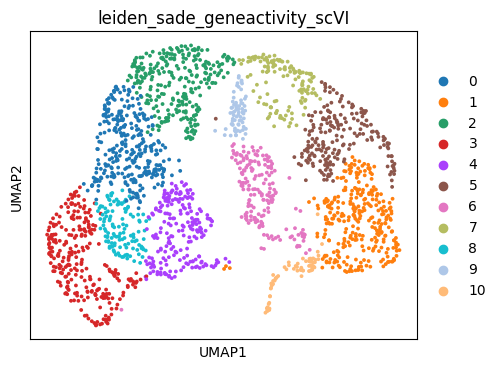

In [ ]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(gene_activity_h5, color=['leiden_sade_geneactivity_scVI'], wspace=0.2, size=30, ncols=3, )

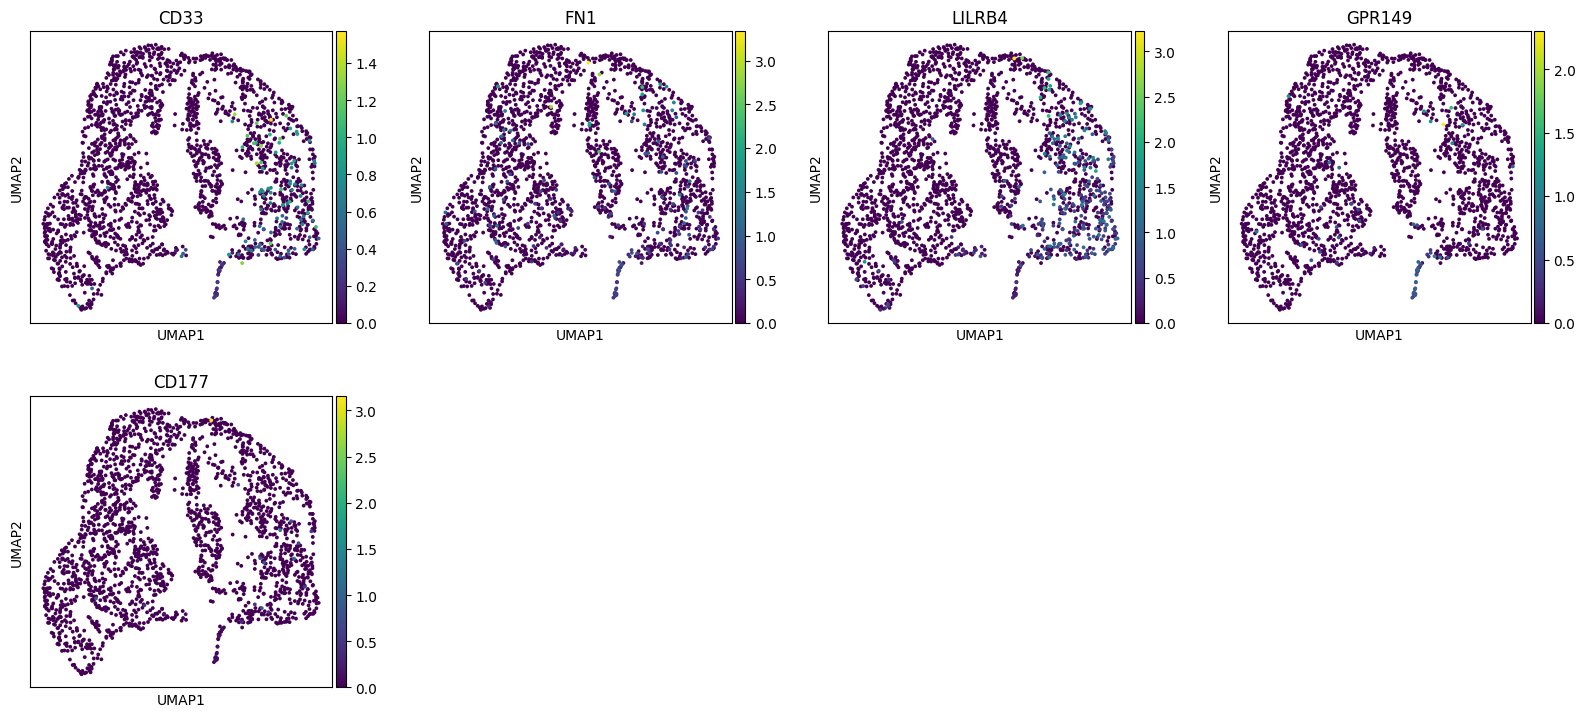

In [75]:
genes = ['CD33', 'FN1', 'LILRB4', 'GPR149', 'CD177']
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(gene_activity_h5, color=genes, wspace=0.2, size=30, ncols=4, layer='log1p_cpm', show=False)

In [40]:
gene_activity_h5.obs.groupby(['leiden_sade_geneactivity_scVI', 'leiden_RNA_scVI']).size().unstack(fill_value=0)

/tmp/ipykernel_574691/1208043962.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gene_activity_h5.obs.groupby(['leiden_sade_geneactivity_scVI', 'leiden_RNA_scVI']).size().unstack(fill_value=0)


leiden_RNA_scVI,0,1,10,11,2,3,4,5,6,7,8,9,no_rna_info
leiden_sade_geneactivity_scVI,,,,,,,,,,,,,
0,0,177,0,0,120,2,0,2,0,1,0,4,0
1,281,0,0,0,0,0,0,0,0,7,7,0,0
2,1,70,5,0,81,64,8,2,39,0,1,5,0
3,0,2,0,0,6,90,0,2,166,0,0,4,0
4,2,107,0,0,44,34,0,6,2,3,12,2,0
5,119,0,1,0,0,0,0,0,0,74,8,3,0
6,0,0,0,0,0,3,0,148,0,1,26,0,0
7,71,0,2,1,3,0,22,2,0,15,5,9,1
8,0,1,0,0,34,83,1,0,0,0,0,5,0


In [60]:
gene_activity_clusters= gene_activity_h5.obs['leiden_sade_geneactivity_scVI'].unique().tolist()


DE_geneactivity_clusters = {}
for cluster in gene_activity_clusters:
    DE_geneactivity_clusters[cluster] =  vae.differential_expression(gene_activity_h5, groupby='leiden_sade_geneactivity_scVI', group1=cluster)


# save DE results
DE_dir = os.path.join(entropy_peaks_subdir,  'DownstreamReanalysis','gene_activity_score_DE_results')
if not os.path.exists(DE_dir):
    os.makedirs(DE_dir)

save_cols = ['lfc_mean', 'neg_log10_pval', 'is_de_fdr_0.05', 'proba_de',  'proba_not_de', 'comparison', 'raw_mean1', 'raw_mean2', 'group1', 'group2']
for c in gene_activity_clusters:
    DE_geneactivity_clusters[c]['neg_log10_pval'] = -np.log10(DE_geneactivity_clusters[c]['proba_not_de'])
    _ = DE_geneactivity_clusters[c].loc[(DE_geneactivity_clusters[c]['is_de_fdr_0.05']) & (DE_geneactivity_clusters[c]['lfc_mean'] > 0.) ].sort_values('lfc_mean', ascending=False)
    _[save_cols].to_csv(os.path.join(DE_dir, f'gene_activity_c_{c}_Up.tsv'), sep='\t')
    _ = DE_geneactivity_clusters[c].loc[(DE_geneactivity_clusters[c]['is_de_fdr_0.05']) & (DE_geneactivity_clusters[c]['lfc_mean'] < 0.) ].sort_values('lfc_mean', ascending=True)
    _[save_cols].to_csv(os.path.join(DE_dir, f'gene_activity_c_{c}_Down.tsv'), sep='\t')

DE...: 100%|██████████| 1/1 [00:02<00:00,  2.87s/it]


In [ ]:
union_cell_info['leiden_sade_geneactivity_scVI'] = union_cell_info.index.map(gene_activity_h5.obs.set_index('atac_bc')['leiden_sade_geneactivity_scVI'])
union_cell_info['leiden_sade_geneactivity_scVI'] = union_cell_info['leiden_sade_geneactivity_scVI'].cat.add_categories('low_signal_out')
union_cell_info['leiden_sade_geneactivity_scVI'] = union_cell_info['leiden_sade_geneactivity_scVI'].fillna('low_signal_out')


union_cell_info.groupby(['leiden_sade_geneactivity_scVI', '_2set_identified_by_atac_SC']).size().unstack(fill_value=0)

/tmp/ipykernel_574691/3297254254.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  union_cell_info.groupby(['leiden_sade_geneactivity_scVI', '_2set_identified_by_atac_SC']).size().unstack(fill_value=0)


_2set_identified_by_atac_SC,both,cr_only,entropy_only,none
leiden_sade_geneactivity_scVI,,,,
0,293,0,13,0
1,293,0,2,0
2,170,28,78,0
3,267,0,3,0
4,211,0,1,0
5,188,2,15,0
6,171,0,7,0
7,60,31,39,1
8,121,0,3,0


# Project gene_activity clustering to SADE-peak-clustering

In [77]:
SADE_atac_cluster_info_subdir = os.path.join(Union_cell_subdir, "SADE_atac_cluster_info")
SADE_atac_cluster_info_file = os.path.join(SADE_atac_cluster_info_subdir, "SADE_atac_cluster_info.tsv")

SADE_atac_cluster_info = pd.read_csv(SADE_atac_cluster_info_file, sep='\t', index_col=0)

In [80]:
SADE_atac_cluster_info['gene_activity_cluster'] = SADE_atac_cluster_info['atac_barcodes'].map(gene_activity_h5.obs.set_index('atac_bc')['leiden_sade_geneactivity_scVI'])

In [84]:
SADE_atac_cluster_info.groupby(['clusters_peakvi_SADE', 'gene_activity_cluster']).size().unstack(fill_value=0)

/tmp/ipykernel_574691/3806546613.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SADE_atac_cluster_info.groupby(['clusters_peakvi_SADE', 'gene_activity_cluster']).size().unstack(fill_value=0)


gene_activity_cluster,0,1,2,3,4,5,6,7,8,9,10
clusters_peakvi_SADE,,,,,,,,,,,
0,239,0,130,7,0,0,0,0,14,0,0
1,0,56,4,0,1,169,3,60,0,0,7
2,0,170,0,0,0,26,0,10,0,0,22
3,0,0,40,168,0,0,2,1,0,0,1
4,0,0,2,0,0,0,149,0,0,56,0
5,43,0,4,0,136,0,0,0,4,0,0
6,3,0,62,65,0,0,0,0,48,1,0
7,19,0,4,30,57,0,2,0,58,0,0
8,0,66,0,0,18,0,12,4,0,0,11
